In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.path import Path
from matplotlib.spines import Spine
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [5]:
# 判断矩阵
criteria = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度', '燃料电池装机综合']
judgment_matrix = np.array([
    [1, 3, 5, 2],
    [1/3, 1, 4, 1/2],
    [1/5, 1/4, 1, 1/3],
    [1/2, 2, 3, 1]
])

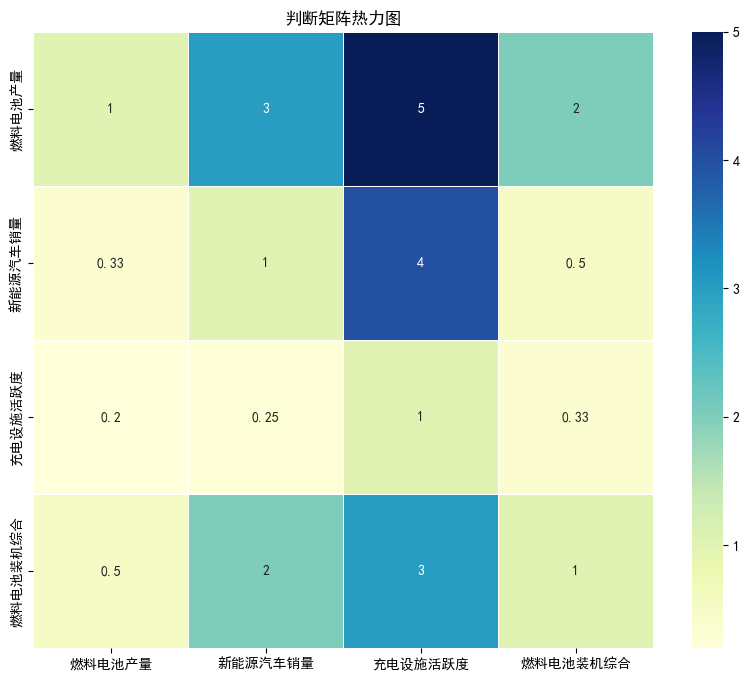

In [7]:
plt.figure(figsize=(10, 8))
sns.heatmap(judgment_matrix, annot=True, cmap='YlGnBu', xticklabels=criteria, yticklabels=criteria, linewidths=0.5)
plt.title('判断矩阵热力图')
plt.show()

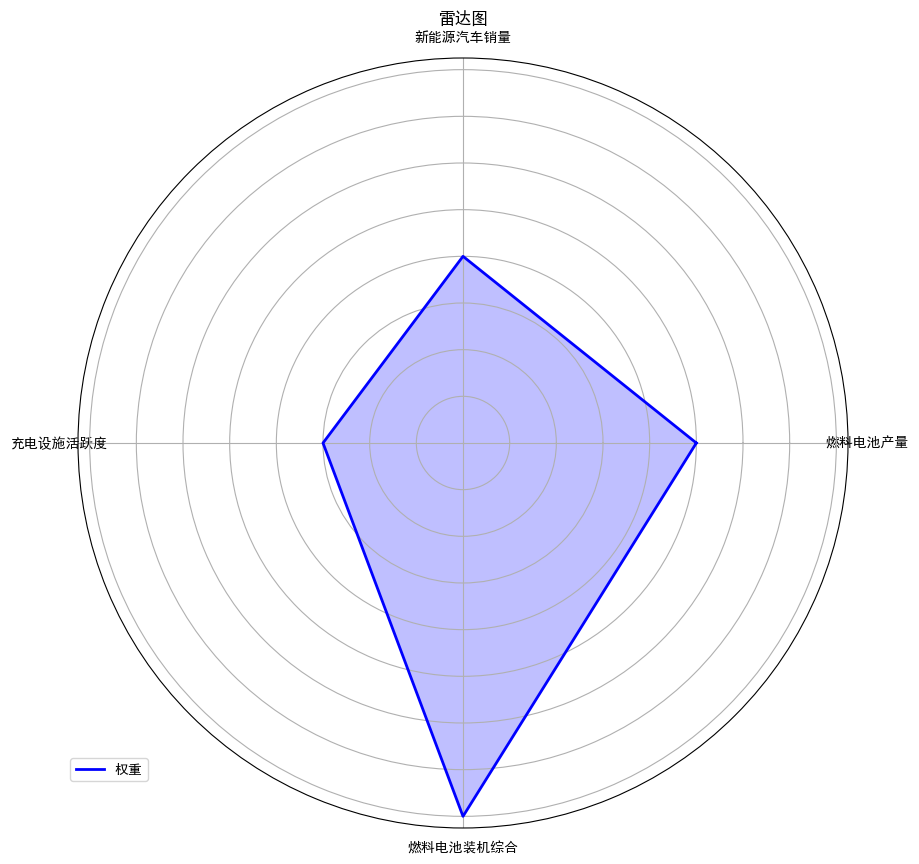

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 权重数据
weights = [0.25, 0.20, 0.15, 0.40]
criteria = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度', '燃料电池装机综合']

# 创建雷达图
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

# 设置雷达图的角度
angles = np.linspace(0, 2 * np.pi, len(criteria), endpoint=False).tolist()
weights += weights[:1]  # 闭合图形
angles += angles[:1]

# 绘制雷达图
ax.fill(angles, weights, 'b', alpha=0.25)
ax.plot(angles, weights, 'b', linewidth=2, label='权重')

# 设置雷达图的标签
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(criteria)

# 添加图例
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

plt.title('雷达图')
plt.show()

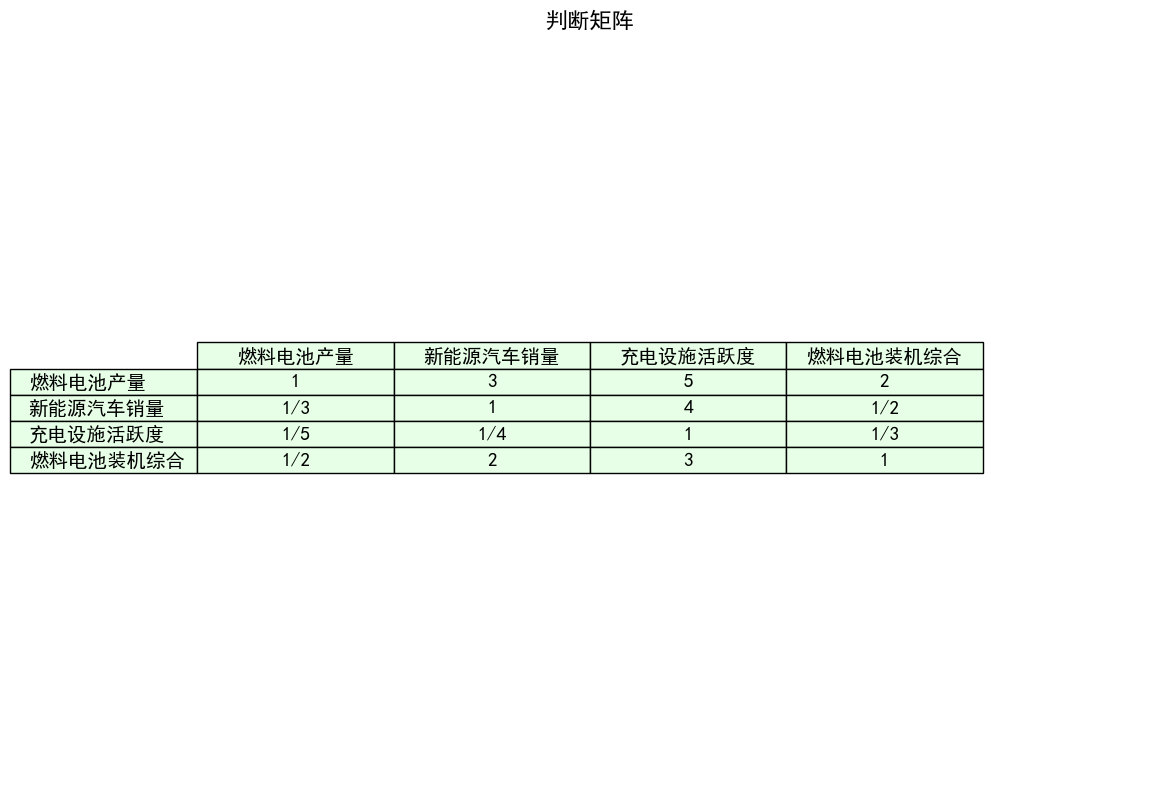

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from fractions import Fraction

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 判断矩阵数据
criteria = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度', '燃料电池装机综合']
data = [
    [1, 3, 5, 2],
    [1/3, 1, 4, 1/2],
    [1/5, 1/4, 1, 1/3],
    [1/2, 2, 3, 1]
]

# 将数值转换为分数形式
def to_fraction(num):
    if num == int(num):
        return f"{int(num)}"
    else:
        return f"{Fraction(num).limit_denominator()}"

# 转换数据为分数形式
fraction_data = []
for row in data:
    fraction_row = [to_fraction(num) for num in row]
    fraction_data.append(fraction_row)

# 创建数据框
df = pd.DataFrame(fraction_data, index=criteria, columns=criteria)

# 创建一个空白的图形
fig, ax = plt.subplots(figsize=(12, 8))

# 隐藏坐标轴
ax.axis('off')

# 创建表格
table = ax.table(cellText=df.values, rowLabels=df.index, colLabels=df.columns, cellLoc='center', loc='center')

# 设置表格样式
table.auto_set_font_size(False)
table.set_fontsize(14)  # 将字体大小设置为14
table.scale(0.7, 1.3)  # 调整表格的宽度和高度比例，使左右间距更小

# 设置表格背景颜色为绿色
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#e6ffe6')  # 浅绿色背景
    cell.set_linewidth(1)
    cell.set_edgecolor('black')

# 设置标题
plt.title('判断矩阵', fontsize=16)

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

一致性比率 CR = (0.0434096866967788+0j), 如果 CR < 0.1，则判断矩阵具有满意的一致性


C:\Users\10414\AppData\Local\Temp\ipykernel_21588\1788601770.py:70: ComplexWarning: Casting complex values to real discards the imaginary part
  weight[i] = a[criterion] * W_j[i] + (1 - a[criterion]) * W_ahp[i]


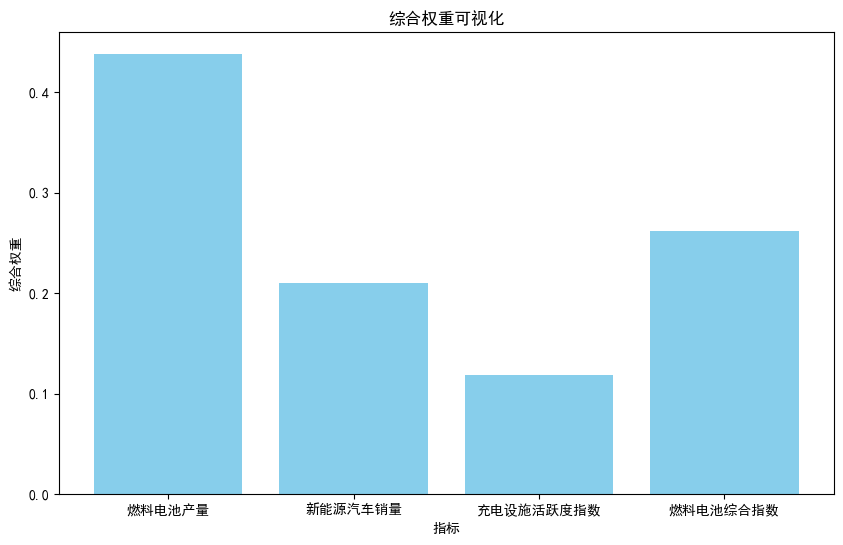

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# 读取数据
data = pd.read_excel('归一化后的热力图数据.xlsx', header=None, skiprows=1)  # 跳过表头
data.columns = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度指数', '燃料电池综合指数']

# 层次分析法计算主观权重
criteria = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度指数', '燃料电池综合指数']
judgment_matrix = np.array([
    [1, 3, 5, 2],
    [1/3, 1, 4, 1/2],
    [1/5, 1/4, 1, 1/3],
    [1/2, 2, 3, 1]
])

# 计算特征向量
eigenvalues = np.linalg.eig(judgment_matrix)[0]
max_eigenvalue = np.max(eigenvalues)
eigenvector = np.linalg.eig(judgment_matrix)[1][:, np.argmax(eigenvalues)]
W_ahp = eigenvector / np.sum(eigenvector)

# 一致性检验
n = len(criteria)
CI = (max_eigenvalue - n) / (n - 1)
RI = [0, 0, 0.58, 0.90, 1.12, 1.24, 1.32, 1.41, 1.45, 1.49, 1.51, 1.48, 1.56, 1.57, 1.59]
CR = CI / RI[n-1]
print(f'一致性比率 CR = {CR}, 如果 CR < 0.1，则判断矩阵具有满意的一致性')

# 熵值法计算客观权重
def entropy_weight(data):
    # 数据归一化
    scaler = MinMaxScaler()
    data_normalized = scaler.fit_transform(data)
    
    # 计算熵值
    entropy = np.zeros(data.shape[1])
    for j in range(data.shape[1]):
        p = data_normalized[:, j] / np.sum(data_normalized[:, j])
        # 避免除以零和对零取对数
        p = np.where(p == 0, 1e-10, p)
        entropy[j] = -np.sum(p * np.log(p))
    
    # 信息熵
    entropy = entropy / np.sum(entropy)
    
    # 冗余度
    redundancy = 1 - entropy
    
    # 权重
    W_j = redundancy / np.sum(redundancy)
    
    return W_j

W_j = entropy_weight(data)

# 权重分配系数
a = {
    '燃料电池产量': 0.15,
    '新能源汽车销量': 0.35,
    '充电设施活跃度指数': 0.25,
    '燃料电池综合指数': 0.25
}

# 计算综合权重
weight = np.zeros(len(criteria))
for i, criterion in enumerate(criteria):
    weight[i] = a[criterion] * W_j[i] + (1 - a[criterion]) * W_ahp[i]

# 可视化
plt.figure(figsize=(10, 6))
plt.bar(criteria, weight, color='skyblue')
plt.xlabel('指标')
plt.ylabel('综合权重')
plt.title('综合权重可视化')
plt.show()

AHP一致性检验通过，CR=0.0434


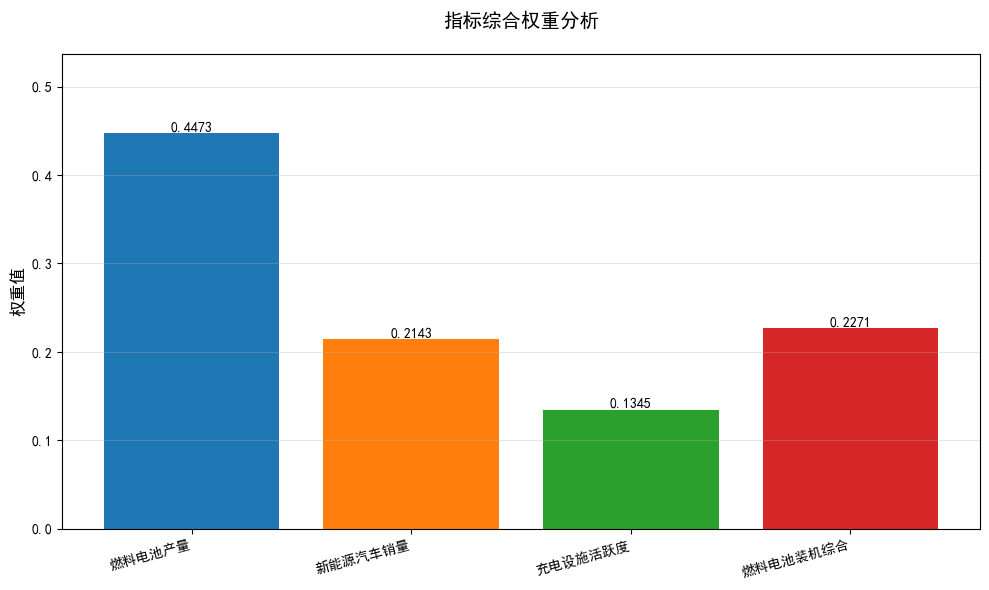

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ahp_weight(judgment_matrix):
    """层次分析法计算主观权重"""
    eigenvalues, eigenvectors = np.linalg.eig(judgment_matrix)
    max_eigen_idx = np.argmax(eigenvalues.real)
    max_eigenvector = eigenvectors[:, max_eigen_idx].real
    Wahp = max_eigenvector / max_eigenvector.sum()
    
    # 一致性检验
    n = judgment_matrix.shape[0]
    CI = (eigenvalues.real[max_eigen_idx] - n) / (n - 1)
    RI = [0, 0, 0.58, 0.90, 1.12][n-1]
    CR = CI / RI
    if CR < 0.1:
        print(f"AHP一致性检验通过，CR={CR:.4f}")
    else:
        print(f"AHP一致性检验未通过，CR={CR:.4f}")
    return Wahp

def entropy_weight(data):
    """熵值法计算客观权重"""
    # 数据归一化处理
    data_norm = data / data.sum(axis=0)
    # 避免零值
    data_norm = data_norm.replace(0, 1e-6)
    # 计算熵值
    entropy = (-data_norm * np.log(data_norm)).sum(axis=0) / np.log(len(data))
    diversity = 1 - entropy
    Wj = diversity / diversity.sum()
    return Wj

# 主程序
if __name__ == "__main__":
    # ------------ AHP部分 ------------
    criteria = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度', '燃料电池装机综合']
    judgment_matrix = np.array([
        [1, 3, 5, 2],
        [1/3, 1, 4, 1/2],
        [1/5, 1/4, 1, 1/3],
        [1/2, 2, 3, 1]
    ])
    Wahp = ahp_weight(judgment_matrix)
    
    # ------------ 熵值法部分 ------------
    try:
        # 读取归一化数据
        df_norm = pd.read_excel('归一化后的热力图数据.xlsx', sheet_name='Sheet1')
        # 规范列名
        df_norm.columns = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度', '燃料电池装机综合']
        # 确保数据为数值型
        df_norm = df_norm.apply(pd.to_numeric, errors='coerce').dropna()
        Wj = entropy_weight(df_norm)
    except Exception as e:
        print("数据读取失败:", str(e))
        exit()
    
    # ------------ 综合权重计算 ------------
    a = np.array([0.15, 0.35, 0.25, 0.25])  # 分配系数
    composite_weight = a * Wj.values + (1 - a) * Wahp
    
    # ------------ 可视化 ------------
    plt.figure(figsize=(10, 6))
    bars = plt.bar(criteria, composite_weight, 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    
    # 添加数值标签
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}',
                 ha='center', va='bottom',
                 fontsize=10)
    
    plt.title('指标综合权重分析', fontsize=14, pad=20)
    plt.ylabel('权重值', fontsize=12)
    plt.xticks(rotation=15, ha='right', fontsize=10)
    plt.ylim(0, composite_weight.max()*1.2)  # 动态调整Y轴范围
    plt.grid(axis='y', alpha=0.3)
    
    # 显示图表
    plt.tight_layout()
    plt.show()

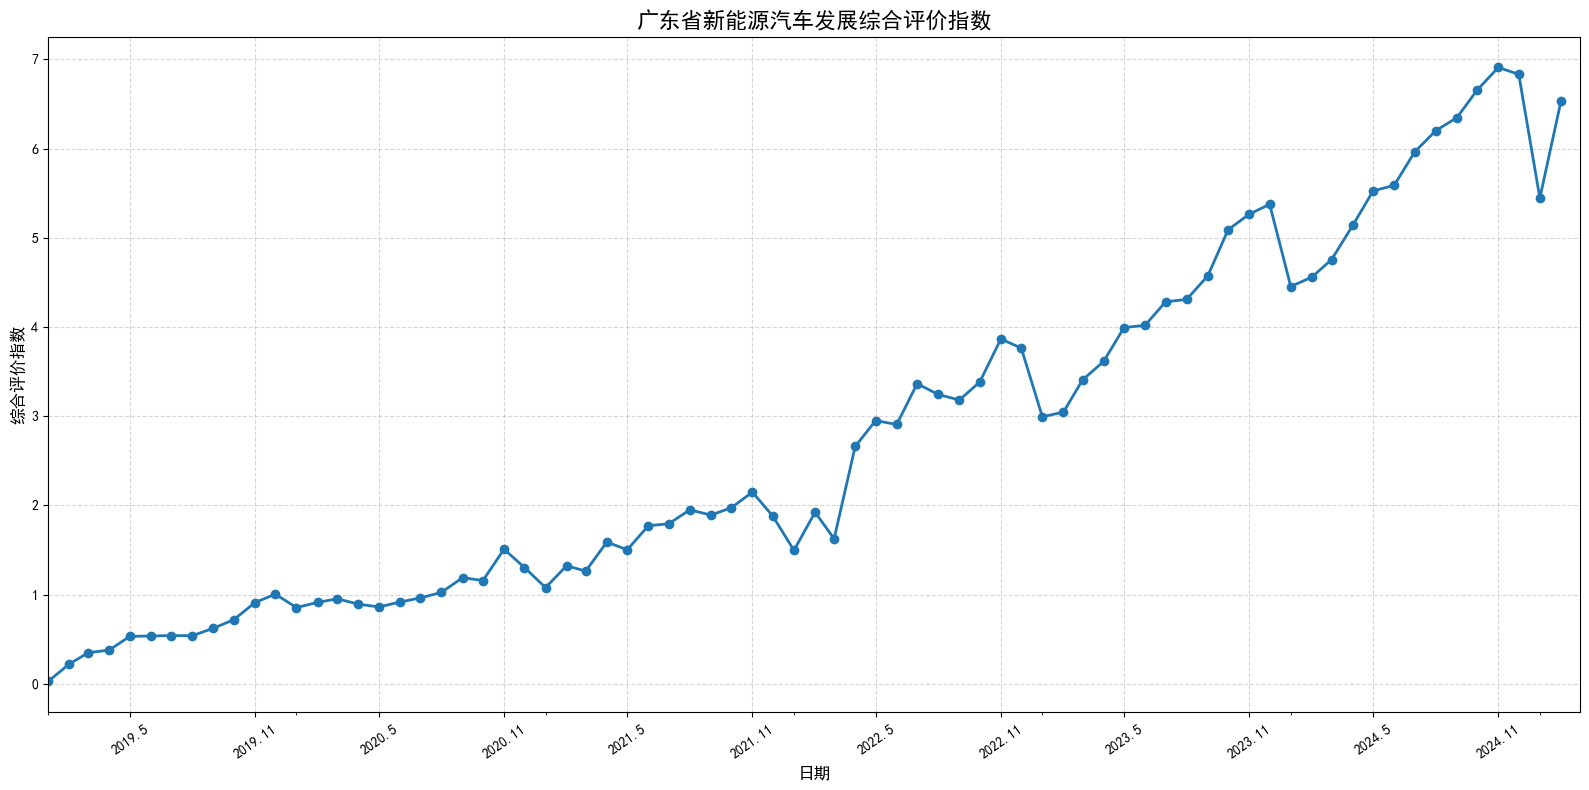

In [5]:

import matplotlib.dates as mdates

n_samples = len(df)
start_date = pd.Timestamp('2019-01-01')
dates = pd.date_range(start=start_date, periods=n_samples, freq='MS')  # MS=每月第一天

plt.figure(figsize=(16, 8))
plt.plot(dates, df['综合评价指数'], marker='o', linestyle='-', linewidth=2)

# 设置坐标轴格式
ax = plt.gca()

# 主刻度：每6个月一个刻度
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
# 次刻度：每年一个刻度（可选）
ax.xaxis.set_minor_locator(mdates.YearLocator())  

# 自定义日期格式（显示为"年.月"且月份无前导零）
def format_func(x, pos=None):
    date = mdates.num2date(x)
    return f"{date.year}.{date.month}"

ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

# 限制坐标轴范围
ax.set_xlim([pd.Timestamp('2019-01-01'), pd.Timestamp('2025-03-01')])

plt.title('广东省新能源汽车发展综合评价指数', fontsize=16)
plt.xlabel('日期', fontsize=12)
plt.ylabel('综合评价指数', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

列名： ['燃料电池产量', '新能源汽车销量', '充电设施活跃度指数', '燃料电池综合指数']
AHP权重： [0.47088335 0.18800552 0.07386722 0.26724391]
熵值法权重： [0.24760238 0.25669067 0.19003232 0.30567463]


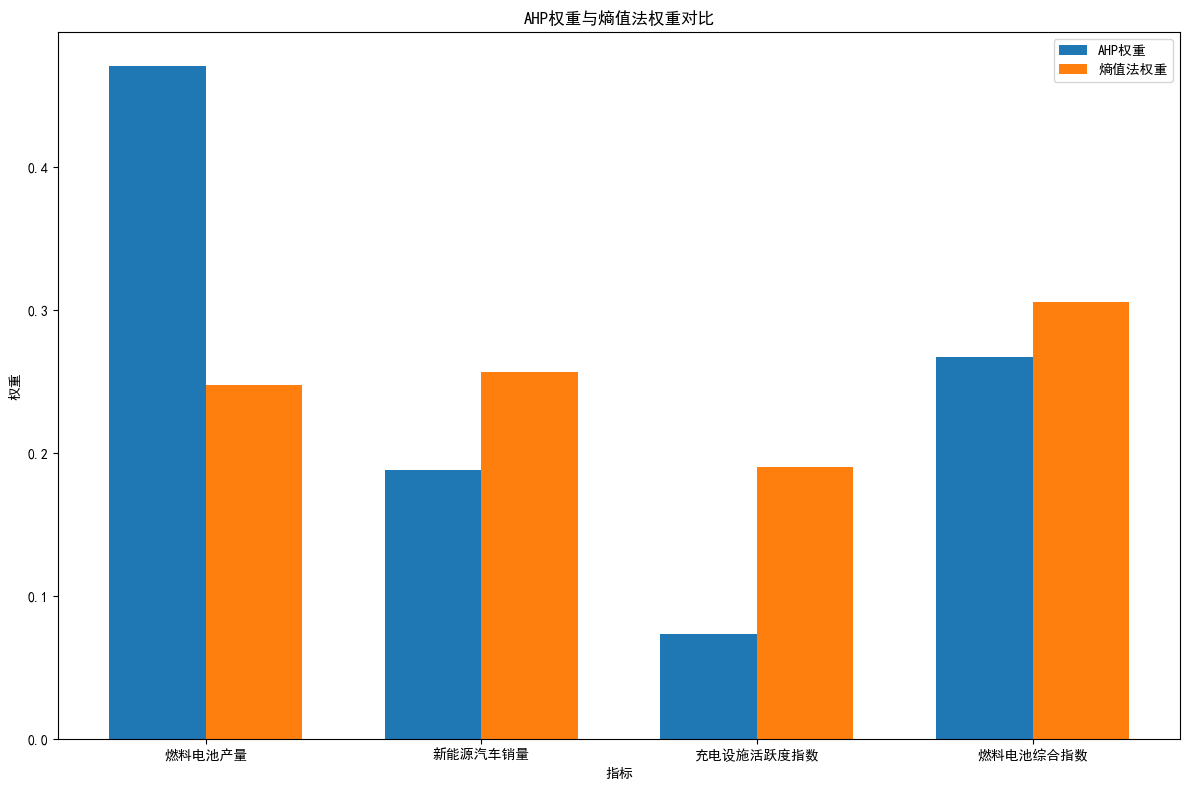

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

file_path = '热力图数据.xlsx'  
df = pd.read_excel(file_path)

print("列名：", df.columns.tolist())

actual_columns = [
    '燃料电池产量',
    '新能源汽车销量',
    '充电设施活跃度指数',
    '燃料电池综合指数'
]

defined_columns = [
    '燃料电池产量',
    '新能源汽车销量',
    '充电设施活跃度指数',
    '燃料电池综合指数'
]

column_mapping = dict(zip(actual_columns, defined_columns))

df.rename(columns=column_mapping, inplace=True)

columns = defined_columns

numeric_df = df[columns].apply(pd.to_numeric, errors='coerce')

# 数据标准化（Min-Max归一化）
for column in columns:
    if column in numeric_df.columns:
        min_val = numeric_df[column].min()
        max_val = numeric_df[column].max()
        df[column + '_normalized'] = (numeric_df[column] - min_val) / (max_val - min_val)
    else:
        print(f"列 '{column}' 不是数值列。")

# 层次分析法（AHP）计算主观权重
judgment_matrix = np.array([
    [1, 3, 5, 2],
    [1/3, 1, 4, 1/2],
    [1/5, 1/4, 1, 1/3],
    [1/2, 2, 3, 1]
])

# 计算特征值和特征向量
eigenvalues, eigenvectors = np.linalg.eig(judgment_matrix)
max_eigenvalue = np.max(eigenvalues)
max_eigenvector = eigenvectors[:, np.argmax(eigenvalues)]
w_ahp = max_eigenvector / np.sum(max_eigenvector)
w_ahp = np.real(w_ahp)

# 熵值法计算客观权重
def calculate_entropy_weights(data):
    # 避免除以零或负数
    data = np.where(data <= 0, 1e-10, data)
    # 计算熵值
    entropy = -data * np.log(data)
    entropy = np.nansum(entropy, axis=0)
    # 计算差异系数
    diff_coeff = 1 - entropy / np.log(len(data))
    # 计算客观权重
    weights = diff_coeff / np.sum(diff_coeff)
    return weights

# 提取归一化后的数据
normalized_columns = [col + '_normalized' for col in columns]
if not all(col in df.columns for col in normalized_columns):
    raise KeyError(f"归一化列 {normalized_columns} 不在数据框中。")

normalized_data = df[normalized_columns].values

# 计算熵值法权重
entropy_weights = calculate_entropy_weights(normalized_data)

# 打印权重
print("AHP权重：", w_ahp)
print("熵值法权重：", entropy_weights)

# 可视化AHP和熵值法权重
labels = ['燃料电池产量', '新能源汽车销量', '充电设施活跃度指数', '燃料电池综合指数']

plt.figure(figsize=(12, 8))
x = np.arange(len(labels))
width = 0.35

plt.bar(x - width/2, w_ahp, width, label='AHP权重')
plt.bar(x + width/2, entropy_weights, width, label='熵值法权重')

plt.xlabel('指标')
plt.ylabel('权重')
plt.title('AHP权重与熵值法权重对比')
plt.xticks(x, labels)
plt.legend()

plt.tight_layout()
plt.show()

列名： ['结束日期', '综合评价指数']
     年份    综合评价指数
0  2019  0.514416
1  2020  0.998367
2  2021  1.669336
3  2022  2.956712
4  2023  4.361425
5  2024  6.029182
6  2025  6.323420


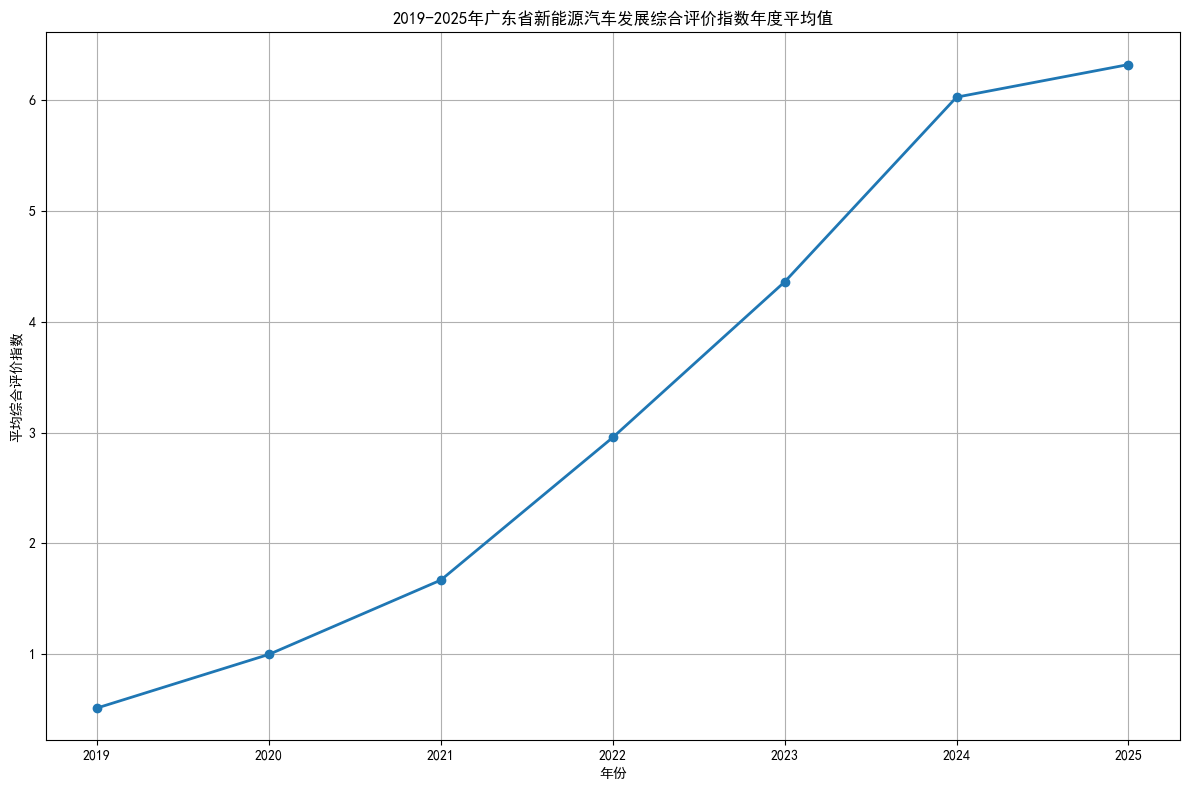

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
file_path = '平均指数.xlsx'  
df = pd.read_excel(file_path)

print("列名：", df.columns.tolist())

df.columns = ['结束日期', '综合评价指数']

# 将“结束日期”列转换为日期格式
df['结束日期'] = pd.to_datetime(df['结束日期'])

# 提取年份
df['年份'] = df['结束日期'].dt.year

# 按年份分组并计算每年的平均综合评价指数
yearly_avg = df.groupby('年份')['综合评价指数'].mean().reset_index()

# 打印每年的平均综合评价指数
print(yearly_avg)

# 可视化每年的平均综合评价指数
plt.figure(figsize=(12, 8))
plt.plot(yearly_avg['年份'], yearly_avg['综合评价指数'], marker='o', linestyle='-', linewidth=2)
plt.title('2019-2025年广东省新能源汽车发展综合评价指数年度平均值')
plt.xlabel('年份')
plt.ylabel('平均综合评价指数')
plt.xticks(yearly_avg['年份'])
plt.grid(True)
plt.tight_layout()
plt.show()